# Multiclass Classification of EEG States

**Project:** neural network in PyTorch Lightning + probability calibration + uncertainty + XAI.

**Presentation goal:** show the entire pipeline in one notebook without waiting for model retraining.

**Data:** `Epileptic Seizure Recognition`, 11,500 samples, 178 EEG time points, 5 classes.

Python library + convolutional neural networks!
Information about the dataset!
Training set + test set -> comparisons
EDA!

In [22]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
from collections import defaultdict
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from scipy.optimize import minimize
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report as sklearn_classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import lightning as L
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

import optuna
from lime.lime_tabular import LimeTabularExplainer

In [23]:
RAW_PATH = Path("data") / "raw" / "data.csv"
PROCESSED_DIR = Path("data") / "processed"
FIGURES_DIR = Path("outputs") / "figures"
TABLES_DIR = Path("outputs") / "tables"
METRICS_DIR = Path("outputs") / "metrics"
MODELS_DIR = Path("outputs") / "models"
LIME_DIR = Path("outputs") / "lime"

In [24]:
SEED = 42
random.seed(SEED)                               # PYTHON
np.random.seed(SEED)                            # NUMPY
torch.manual_seed(SEED)                         # PYTORCH
L.seed_everything(SEED, workers=True)           # PYTORCH LIGHTNING + DATALOADER WORKERS
# MATRIX MULTIPLICATION PRECISION


Seed set to 42


In [25]:
LABELS = {
    1: "epileptic_seizure",
    2: "tumor_area_eeg",
    3: "healthy_area_eeg",
    4: "eyes_closed",
    5: "eyes_open",
}
CLASS_NAMES = [LABELS[i] for i in sorted(LABELS)]

CLASS_NAMES

['epileptic_seizure',
 'tumor_area_eeg',
 'healthy_area_eeg',
 'eyes_closed',
 'eyes_open']

## 1. Data Source

The dataset comes from Kaggle: **Epileptic Seizure Recognition**.

Link: https://www.kaggle.com/datasets/harunshimanto/epileptic-seizure-recognition

In [26]:
raw = pd.read_csv(RAW_PATH)
raw.shape

(11500, 180)

In [27]:
# Raw data: identifier, 178 EEG signal points, and class y.
raw[["Unnamed", "X1", "X2", "X3", "X4", "X5", "X178","y"]].head()

,Unnamed,X1,X2,X3,X4,X5,X178,y
0,X21.V1.791,135,190,229,223,192,-51,4
1,X15.V1.924,386,382,356,331,320,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-73,5


### Conclusions So Far

- The dataset has 11,500 observations and 178 EEG signal points.
- The `Unnamed` column looks like a sample identifier, so it should not be used as a model feature -> we prefer not to learn from labels or technical IDs.

## 2. What Do the `X1-X178` Features Mean?

These are not descriptive clinical features such as age, BMI, or diagnosis.

`X1`, `X2`, ..., `X178` are consecutive time points of one EEG signal segment. One row represents:

```text
EEG segment -> 178 signal amplitudes -> one class y
```

Therefore, in XAI we interpret the importance of signal points or signal segments, not the importance of classic medical features.

In [28]:
feature_cols = [c for c in raw.columns if c.startswith("X")]
class_counts = raw["y"].value_counts().sort_index().rename_axis("klasa").reset_index(name="liczba_probek")
class_counts

,klasa,liczba_probek
0,1,2300
1,2,2300
2,3,2300
3,4,2300
4,5,2300


### Conclusion After the Class Table

- The classes are perfectly balanced: each class has 2,300 samples.
- A balanced distribution means the model should not gain an easy advantage by predicting one dominant class. The result should therefore be evaluated by its real ability to distinguish signal shapes.

## 3. Classes in the Problem

| `y` | Meaning |
|---:|---|
| 1 | epileptic seizure |
| 2 | EEG recording from the tumor area |
| 3 | EEG recording from a healthy brain area of a patient with a tumor |
| 4 | eyes closed |
| 5 | eyes open |

## 4. Cleaning and Preprocessing

Main steps:

1. Remove the `Unnamed` column because it is an identifier, not a model feature.
2. Check missing values and duplicates.
3. Recode the target: `target = y - 1`, meaning classes `0-4` for PyTorch.
4. Stratified split: train 70%, validation 15%, test 15%.
5. Mild clipping of extreme values using the 0.001 and 0.999 quantiles calculated on the training set.
6. Standardization with `StandardScaler` fitted only on the training set.

## Preprocessing Code

This section does what would normally be split into project modules:
- cleans the data,
- creates the target,
- splits the data into train/validation/test sets,
- clips extreme values,
- standardizes the features.

In [ ]:
def clean_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Usuwa techniczne kolumny i tworzy target w formacie 0-4."""
    cleaned = df.copy()
    cleaned = cleaned.drop(columns=[c for c in ["Unnamed"] if c in cleaned.columns], errors="ignore")
    cleaned = cleaned.drop_duplicates()
    cleaned["target"] = cleaned["y"].astype(int) - 1
    return cleaned


def feature_columns(df: pd.DataFrame) -> list[str]:
    """Zwraca kolumny X1-X178, czyli punkty czasowe sygnału EEG."""
    return [c for c in df.columns if c.upper().startswith("X")]


def prepare_model_inputs(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, list[str]]:
    """Rozdziela cechy i target oraz ustawia typy zgodne z PyTorch."""
    features = feature_columns(df)
    x = df[features].astype("float32")
    y = df["target"].astype("int64")
    return x, y, features


def split_train_val_test(
    x: pd.DataFrame,
    y: pd.Series,
    test_size: float = 0.15,
    val_size: float = 0.15,
    random_state: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series, pd.Series]:
    """Tworzy stratyfikowany podział train/validation/test."""
    holdout_size = val_size + test_size
    if not 0 < holdout_size < 1:
        raise ValueError("test_size + val_size musi być z przedzialu (0, 1)")

    x_train, x_holdout, y_train, y_holdout = train_test_split(
        x,
        y,
        test_size=holdout_size,
        stratify=y,
        random_state=random_state,
    )

    test_share_in_holdout = test_size / holdout_size
    x_val, x_test, y_val, y_test = train_test_split(
        x_holdout,
        y_holdout,
        test_size=test_share_in_holdout,
        stratify=y_holdout,
        random_state=random_state,
    )
    return x_train, x_val, x_test, y_train, y_val, y_test


def clip_outliers_from_train(
    x_train: pd.DataFrame,
    x_val: pd.DataFrame,
    x_test: pd.DataFrame,
    clip_quantiles: tuple[float, float] = (0.001, 0.999),
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Przycina wartości odstające według granic policzonych tylko na train."""
    low_q, high_q = clip_quantiles
    low = x_train.quantile(low_q)
    high = x_train.quantile(high_q)
    return (
        x_train.clip(low, high, axis=1),
        x_val.clip(low, high, axis=1),
        x_test.clip(low, high, axis=1),
    )


def scale_features(
    x_train: pd.DataFrame,
    x_val: pd.DataFrame,
    x_test: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, StandardScaler]:
    """Standaryzuje cechy, dopasowując scaler tylko na zbiorze treningowym."""
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train).astype("float32")
    x_val_scaled = scaler.transform(x_val).astype("float32")
    x_test_scaled = scaler.transform(x_test).astype("float32")
    return x_train_scaled, x_val_scaled, x_test_scaled, scaler


def build_splits(
    x_train: np.ndarray,
    x_val: np.ndarray,
    x_test: np.ndarray,
    y_train: pd.Series,
    y_val: pd.Series,
    y_test: pd.Series,
    features: list[str],
    scaler: StandardScaler,
) -> dict:
    """Składa dane w strukturę używaną przez dalsze komórki notebooka."""
    return {
        "x_train": x_train,
        "y_train": y_train.to_numpy(dtype="int64"),
        "x_val": x_val,
        "y_val": y_val.to_numpy(dtype="int64"),
        "x_test": x_test,
        "y_test": y_test.to_numpy(dtype="int64"),
        "feature_names": features,
        "scaler": scaler,
    }


def save_processed_splits(splits: dict, features: list[str]) -> None:
    """Zapisuje przetworzone zbiory train/validation/test do CSV."""
    for split_name in ["train", "val", "test"]:
        pd.DataFrame(splits[f"x_{split_name}"], columns=features).assign(
            target=splits[f"y_{split_name}"]
        ).to_csv(PROCESSED_DIR / f"{split_name}.csv", index=False)


def split_and_scale(
    df: pd.DataFrame,
    test_size: float = 0.15,
    val_size: float = 0.15,
    random_state: int = SEED,
    clip_quantiles: tuple[float, float] = (0.001, 0.999),
) -> dict:
    """Uruchamia kompletny preprocessing: split, clipping, skalowanie i zapis plików."""
    x, y, features = prepare_model_inputs(df)
    x_train, x_val, x_test, y_train, y_val, y_test = split_train_val_test(
        x,
        y,
        test_size=test_size,
        val_size=val_size,
        random_state=random_state,
    )
    x_train, x_val, x_test = clip_outliers_from_train(
        x_train,
        x_val,
        x_test,
        clip_quantiles=clip_quantiles,
    )
    x_train, x_val, x_test, scaler = scale_features(x_train, x_val, x_test)

    splits = build_splits(x_train, x_val, x_test, y_train, y_val, y_test, features, scaler)
    save_processed_splits(splits, features)

    return splits


In [30]:
# Run preprocessing.

cleaned = clean_dataframe(raw)
feature_cols = feature_columns(cleaned)
splits = split_and_scale(cleaned)

cleaning_summary = pd.DataFrame({
    "n_rows": [len(cleaned)],
    "n_features": [len(feature_cols)],
    "missing_values": [int(cleaned[feature_cols + ["y"]].isna().sum().sum())],
    "duplicates": [int(cleaned.duplicated().sum())],
})
cleaning_summary.to_csv(TABLES_DIR / "data_cleaning_summary.csv", index=False)

cleaned["y"].value_counts().sort_index().rename_axis("class").reset_index(name="count").to_csv(
    TABLES_DIR / "class_distribution.csv", index=False
)
cleaned[feature_cols].describe().T.to_csv(TABLES_DIR / "feature_describe.csv")

print("Surowe dane:", raw.shape)
print("Dane po cleaningu:", cleaned.shape)
print("Train/val/test:", splits["x_train"].shape, splits["x_val"].shape, splits["x_test"].shape)
cleaning_summary

Surowe dane: (11500, 180)
Dane po cleaningu: (11500, 180)
Train/val/test: (8050, 178) (1725, 178) (1725, 178)


,n_rows,n_features,missing_values,duplicates
0,11500,178,0,0


## 5. EDA - What Can We See in the Data?

EDA mainly shows three things:

- the classes are perfectly balanced,
- signals from different classes have different shapes and amplitudes,
- the seizure class is the most distinctive, while classes 2 and 3 are harder to distinguish.

## EDA Code

This section generates exploratory plots.

In [31]:
def run_eda_inline(df: pd.DataFrame, splits: dict) -> None:
    features = feature_columns(df)
    order = sorted(df["y"].unique())

    # class counts
    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x="y", order=order)
    plt.title("Class distribution")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=180)
    plt.close()

    # single EEG signal (one example sample) from each class
    plt.figure(figsize=(10, 6))
    for cls in order:
        sample = df[df["y"] == cls].iloc[0][features].to_numpy()
        plt.plot(sample, label=f"class {cls}", linewidth=1)
    plt.title("Example EEG signals by class")
    plt.xlabel("Time point")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "example_signals.png", dpi=180)
    plt.close()

    # mean signal for each class
    plt.figure(figsize=(10, 6))
    for cls in order:
        mean_signal = df[df["y"] == cls][features].mean(axis=0).to_numpy()
        plt.plot(mean_signal, label=f"class {cls}", linewidth=1.5)
    plt.title("Mean EEG signal by class")
    plt.xlabel("Time point")
    plt.ylabel("Mean amplitude")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "mean_signals.png", dpi=180)
    plt.close()

    eda = df[["y"]].copy()
    eda["signal_mean"] = df[features].mean(axis=1)
    eda["signal_std"] = df[features].std(axis=1)
    eda["signal_min"] = df[features].min(axis=1)
    eda["signal_max"] = df[features].max(axis=1)
    eda["signal_energy"] = (df[features] ** 2).sum(axis=1)
    eda.describe().T.to_csv(TABLES_DIR / "signal_level_features_describe.csv")

    plt.figure(figsize=(7, 5))
    sns.boxplot(data=eda, x="y", y="signal_energy")
    plt.title("Signal energy by class")
    plt.xlabel("Class")
    plt.ylabel("Energy")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "signal_energy_by_class.png", dpi=180)
    plt.close()

    pca = PCA(n_components=2, random_state=SEED)
    x_pca = pca.fit_transform(splits["x_train"])
    plt.figure(figsize=(7, 5))
    scatter = plt.scatter(x_pca[:, 0], x_pca[:, 1], c=splits["y_train"], s=8, alpha=0.55, cmap="tab10")
    plt.title("PCA of scaled training samples")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(scatter, label="Encoded class")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "pca_train.png", dpi=180)
    plt.close()

run_eda_inline(cleaned, splits)
print("EDA figures saved in", FIGURES_DIR)

EDA figures saved in outputs\figures


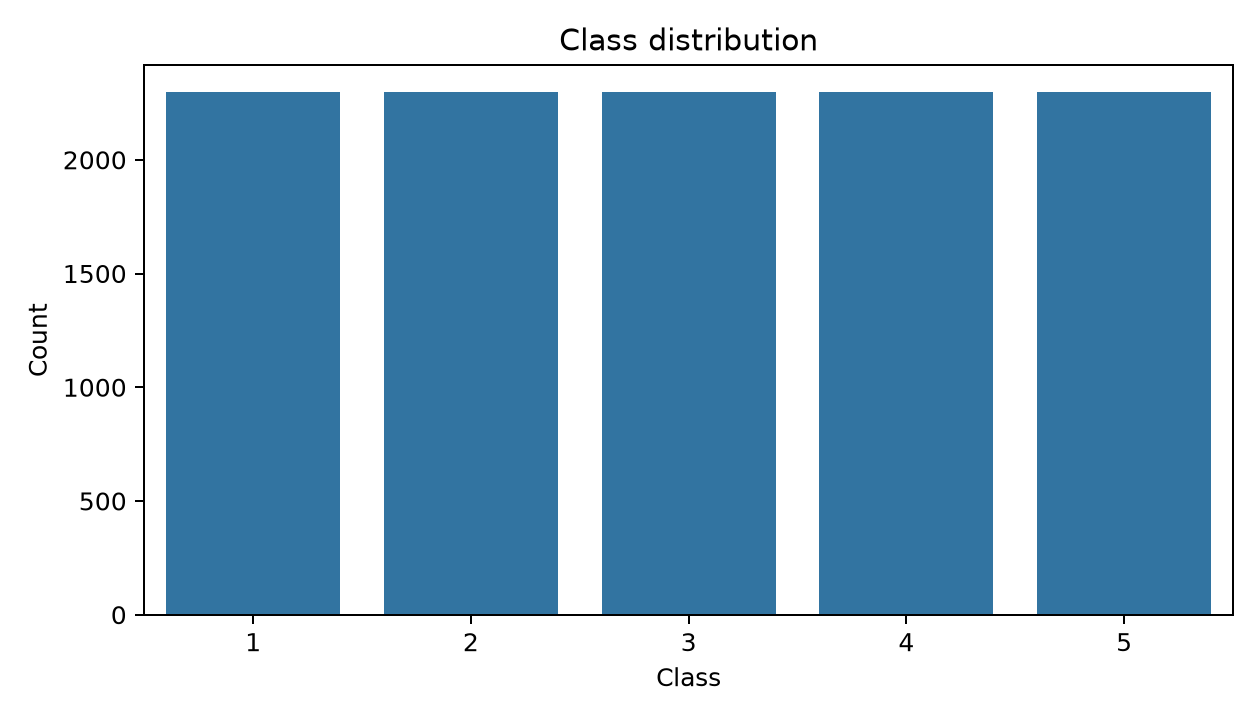

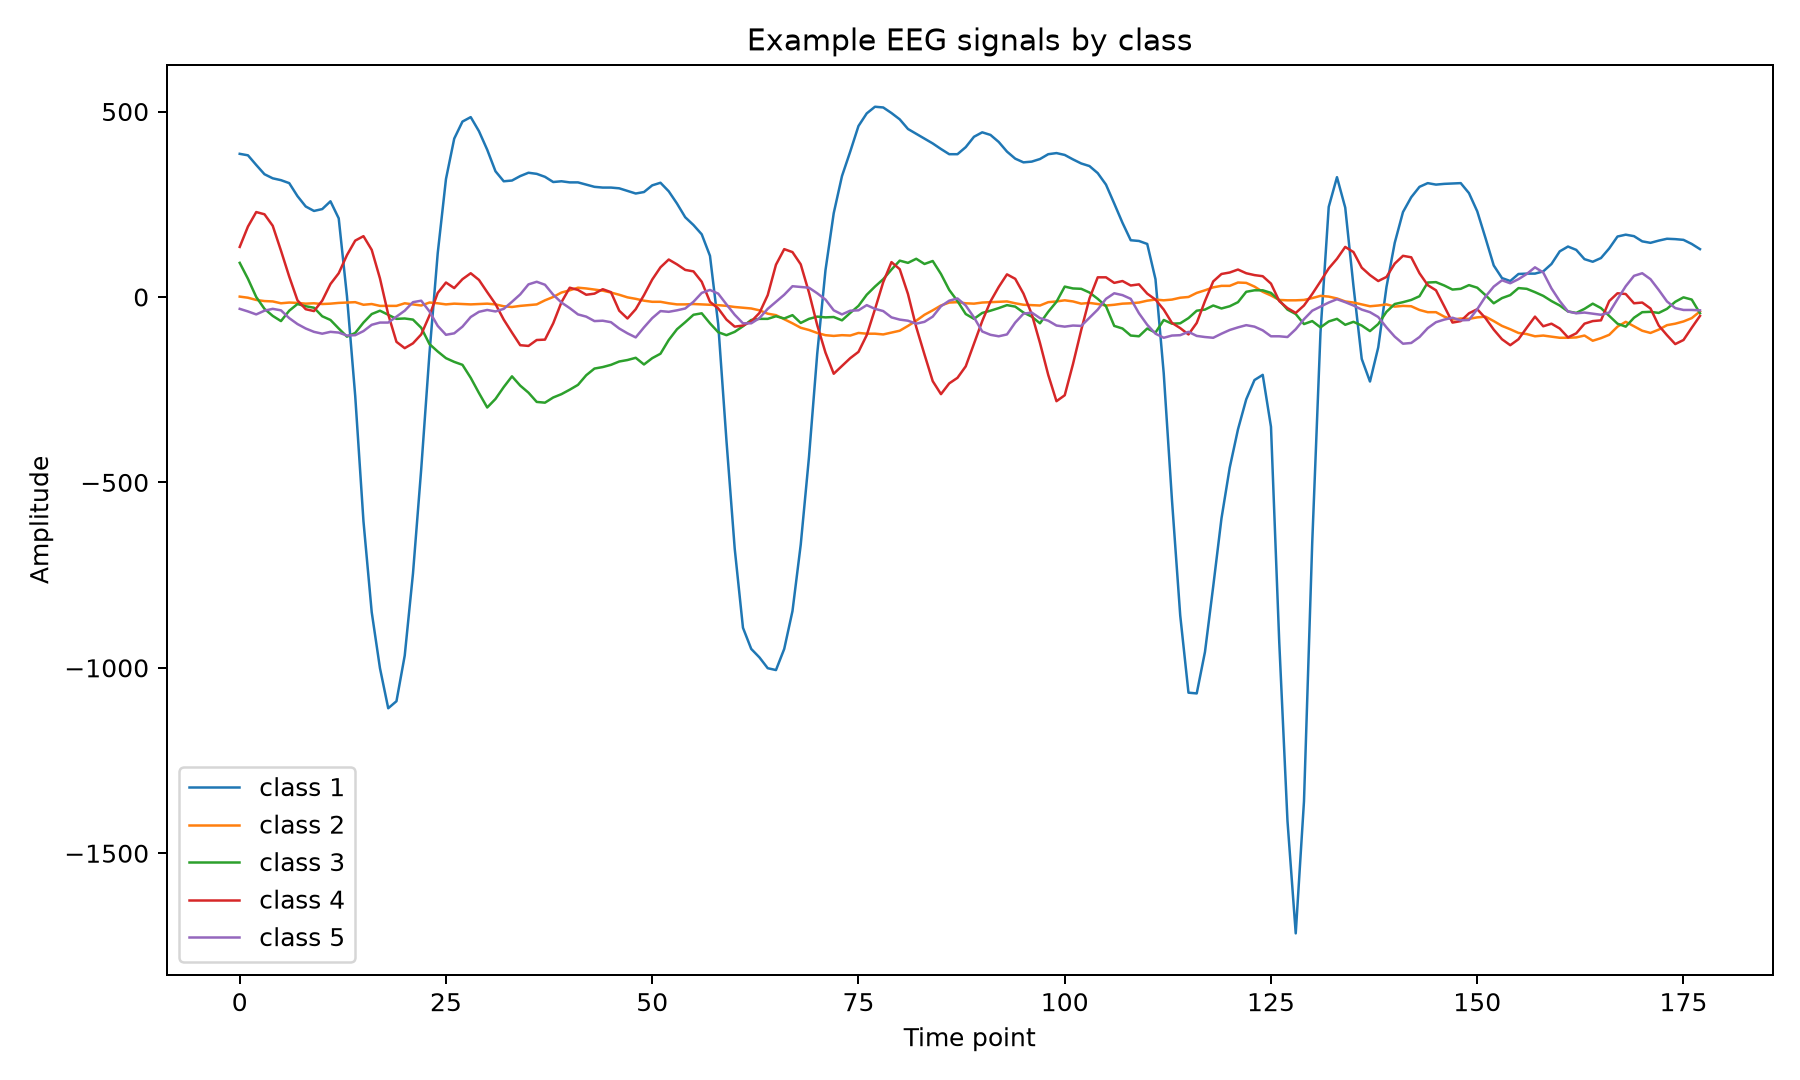

In [32]:
display(Image(filename=str(FIGURES_DIR / "class_distribution.png")))
display(Image(filename=str(FIGURES_DIR / "example_signals.png")))

### Conclusion After the Class Distribution and Example Signal Plots
Classes 2, 3, 4, and 5 are more similar to each other than class 1, although they differ locally in amplitude level and frequency of changes. This observation suggests that class 1 should be easier for the model to recognize, while distinguishing the remaining classes may be more difficult.

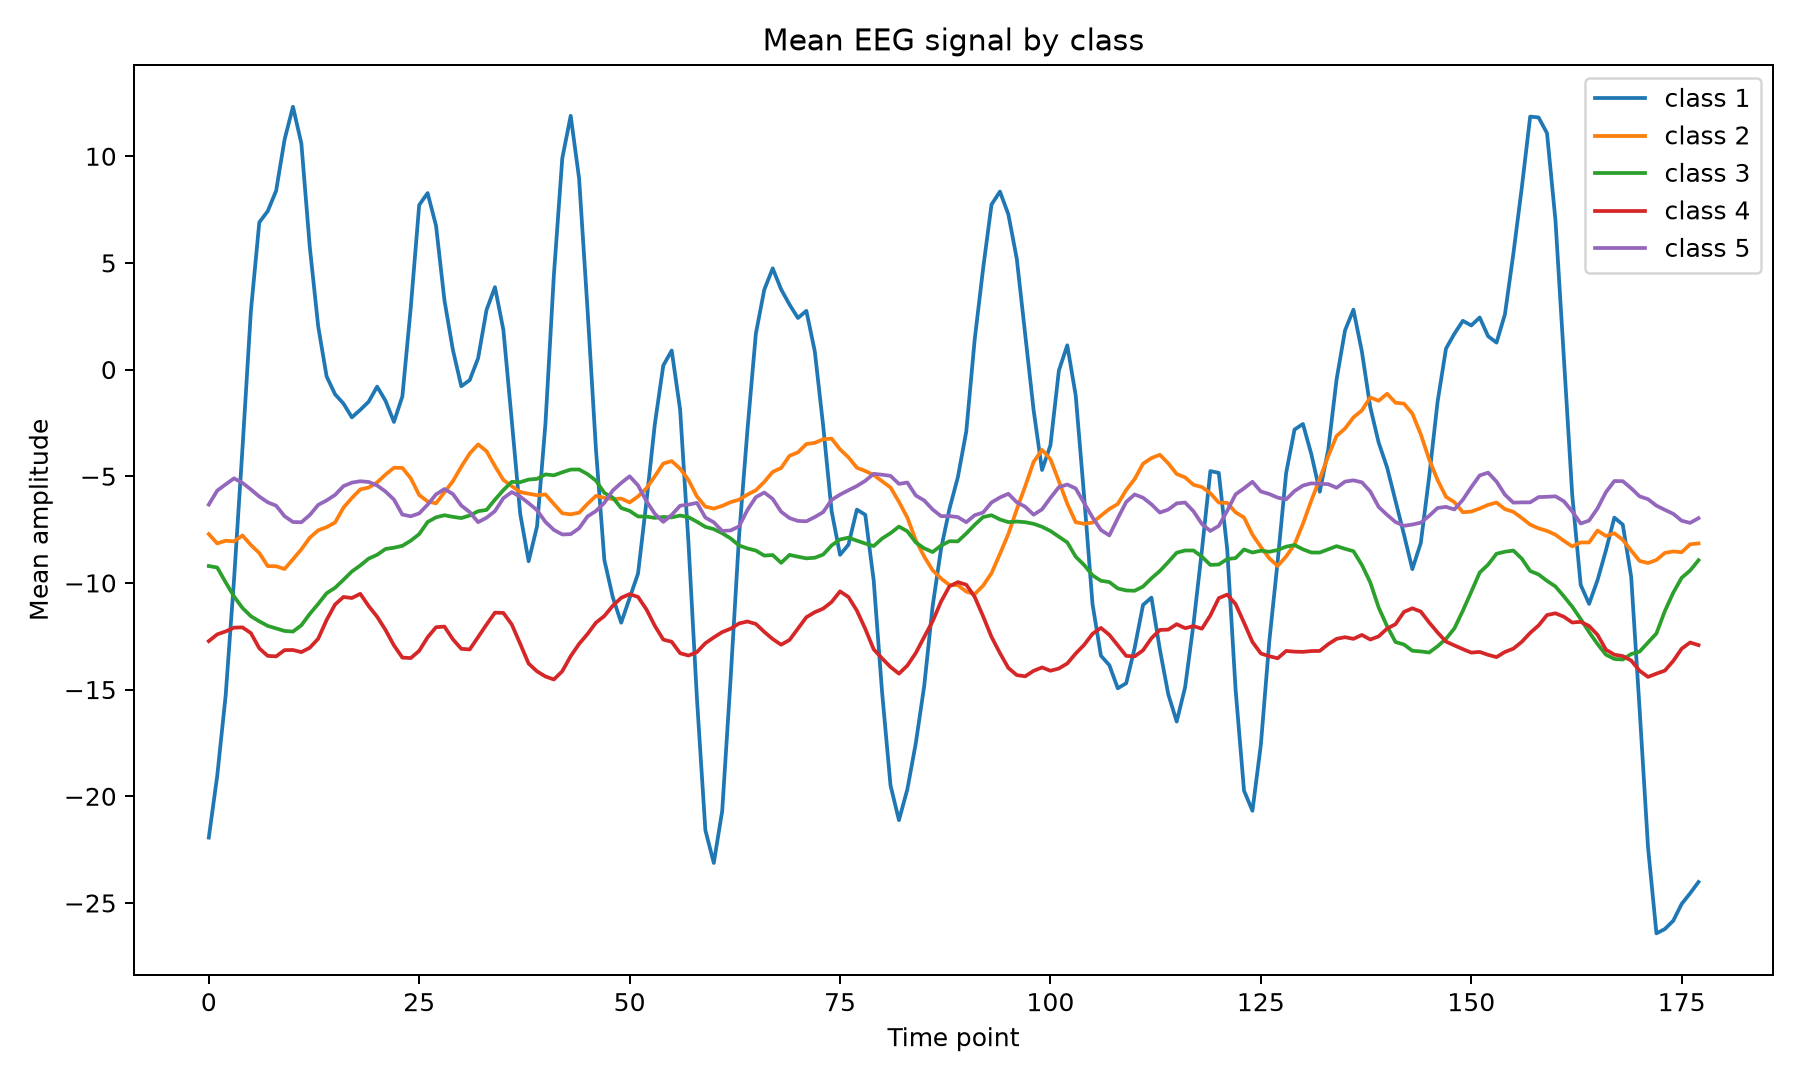

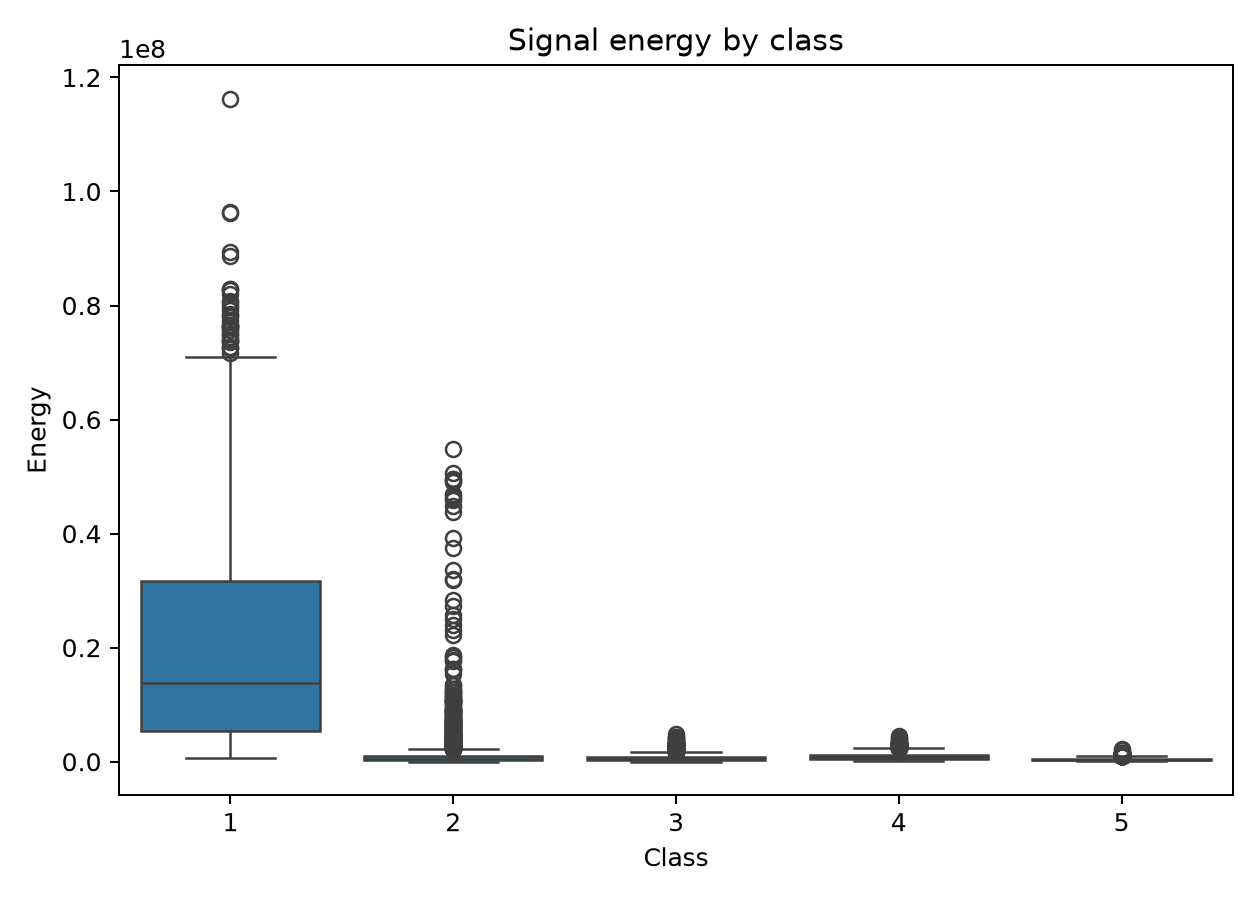

In [33]:
display(Image(filename=str(FIGURES_DIR / "mean_signals.png")))
display(Image(filename=str(FIGURES_DIR / "signal_energy_by_class.png")))

### Conclusion After Mean Signals and Energy

- The mean waveforms suggest that the seizure class has the most distinctive amplitude profile, which is later reflected in the highest F1 score for `epileptic_seizure`.
- Class 1 clearly has the highest signal energy and the greatest variability. The remaining classes have lower energy and are more similar to each other, which suggests that distinguishing them using only this feature is harder.

## 6. Model

The model used here is an MLP in PyTorch Lightning.

Architecture:

```text
178 EEG points
-> Linear + BatchNorm + ReLU + Dropout
-> Linear + BatchNorm + ReLU + Dropout
-> Linear + BatchNorm + ReLU + Dropout
-> 5 classes
```

Loss function: `CrossEntropyLoss`. Optimizer: `AdamW`. Hyperparameters were selected with Optuna.

## Model and Evaluation Code


### DataModule for PyTorch Lightning

This cell converts the prepared NumPy arrays into `TensorDataset` objects and defines three dataloaders: training, validation, and test.


In [34]:
class EEGDataModule(L.LightningDataModule):
    def __init__(self, splits: dict, batch_size: int = 128):
        super().__init__()
        self.splits = splits
        self.batch_size = batch_size

    def setup(self, stage: str | None = None) -> None:
        self.train_ds = self._dataset(self.splits["x_train"], self.splits["y_train"])
        self.val_ds = self._dataset(self.splits["x_val"], self.splits["y_val"])
        self.test_ds = self._dataset(self.splits["x_test"], self.splits["y_test"])

    @staticmethod
    def _dataset(x: np.ndarray, y: np.ndarray) -> TensorDataset:
        return TensorDataset(torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long))

    def train_dataloader(self) -> DataLoader:
        return DataLoader(self.train_ds, batch_size=self.batch_size, shuffle=True, num_workers=0)

    def val_dataloader(self) -> DataLoader:
        return DataLoader(self.val_ds, batch_size=self.batch_size, shuffle=False, num_workers=0)

    def test_dataloader(self) -> DataLoader:
        return DataLoader(self.test_ds, batch_size=self.batch_size, shuffle=False, num_workers=0)


### MLP Configuration and Architecture

This cell contains the model hyperparameter configuration and the MLP itself: linear layers, BatchNorm, ReLU, and Dropout.


In [ ]:
@dataclass
class ModelConfig:
    input_dim: int = 178
    num_classes: int = 5
    hidden_dims: list[int] = None
    dropout: float = 0.3
    learning_rate: float = 0.001
    weight_decay: float = 0.0001


class EEGMLP(L.LightningModule):
    def __init__(self, cfg: ModelConfig):
        super().__init__()
        self.save_hyperparameters()
        hidden_dims = cfg.hidden_dims or [256, 128, 64]
        layers = []
        in_dim = cfg.input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(in_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(cfg.dropout),
            ])
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, cfg.num_classes))
        self.net = nn.Sequential(*layers)
        self.loss_fn = nn.CrossEntropyLoss()
        self.learning_rate = cfg.learning_rate
        self.weight_decay = cfg.weight_decay

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def training_step(self, batch, batch_idx: int) -> torch.Tensor:
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = logits.argmax(dim=1)
        acc = (preds == y).float().mean()
        self.log("train_loss", loss, prog_bar=False)
        self.log("train_acc", acc, prog_bar=False)
        return loss

    def validation_step(self, batch, batch_idx: int) -> None:
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        preds = logits.argmax(dim=1)
        macro_f1 = f1_score(y.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
        acc = (preds == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)
        self.log("val_macro_f1", macro_f1, prog_bar=True)

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay) # AdamW -> weight decay
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)   # learning rate adaptation
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_macro_f1"}}


### Model Creation and Trainer Configuration

These functions build a model from default or discovered hyperparameters and create a PyTorch Lightning `Trainer` object.


In [36]:
def make_model(overrides: dict | None = None) -> EEGMLP:
    overrides = overrides or {}
    cfg = ModelConfig(
        input_dim=178,
        num_classes=5,
        hidden_dims=overrides.get("hidden_dims", [256, 128, 64]),
        dropout=overrides.get("dropout", 0.3),
        learning_rate=overrides.get("learning_rate", 0.001),
        weight_decay=overrides.get("weight_decay", 0.0001),
    )
    return EEGMLP(cfg)


def trainer_for(callbacks: list | None = None, checkpointing: bool = False, quiet: bool = False) -> L.Trainer:
    return L.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator="cpu",
        devices=1,
        callbacks=callbacks or [],
        logger=False,
        enable_checkpointing=checkpointing,
        enable_progress_bar=not quiet,
        deterministic=True,
    )


### Prediction and Probability Calibration

This block contains functions for computing logits, applying softmax, and performing simple calibration with temperature scaling.


In [ ]:
# logits -> probabilities
def softmax(logits: np.ndarray) -> np.ndarray:
    logits = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(logits)
    return exp / exp.sum(axis=1, keepdims=True)


def predict_logits(model: torch.nn.Module, x: np.ndarray, batch_size: int = 512) -> np.ndarray:
    model.eval()
    outputs = []
    with torch.no_grad():
        for start in range(0, len(x), batch_size):
            xb = torch.tensor(x[start:start + batch_size], dtype=torch.float32)
            outputs.append(model(xb).detach().cpu().numpy())
    return np.concatenate(outputs, axis=0)


class TemperatureScaler:
    def __init__(self):
        self.temperature = 1.0

    def fit(self, logits: np.ndarray, y_true: np.ndarray):
        logits = np.asarray(logits, dtype=np.float64)
        y_true = np.asarray(y_true, dtype=np.int64)

        def objective(log_t: np.ndarray) -> float:
            temp = float(np.exp(log_t[0]))
            probs = softmax(logits / temp)
            return log_loss(y_true, probs, labels=list(range(probs.shape[1])))

        result = minimize(objective, x0=np.array([0.0]), method="Nelder-Mead")
        self.temperature = float(np.exp(result.x[0]))
        return self

    def transform_logits(self, logits: np.ndarray) -> np.ndarray:
        return np.asarray(logits) / self.temperature


### Metrics and Evaluation Plots

This section defines functions for computing metrics, the classification report, the confusion matrix, and the reliability diagram.


In [ ]:
# How well is the model calibrated overall?

# model confidence vs actual accuracy -> ECE
def expected_calibration_error(y_true: np.ndarray, probs: np.ndarray, n_bins: int = 15) -> float:
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    correct = predictions == y_true
    ece = 0.0
    bins = np.linspace(0, 1, n_bins + 1)
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.any():
            ece += mask.mean() * abs(correct[mask].mean() - confidences[mask].mean())
    return float(ece)

# how close the full predicted probability vector is to the truth
def multiclass_brier(y_true: np.ndarray, probs: np.ndarray) -> float:
    y_onehot = np.eye(probs.shape[1])[y_true]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))


def metrics_dict(y_true: np.ndarray, probs: np.ndarray) -> dict[str, float]:
    preds = probs.argmax(axis=1)
    values = {
        "accuracy": accuracy_score(y_true, preds),
        "balanced_accuracy": balanced_accuracy_score(y_true, preds),
        "macro_f1": f1_score(y_true, preds, average="macro"),
        "weighted_f1": f1_score(y_true, preds, average="weighted"),
        "nll": log_loss(y_true, probs, labels=list(range(probs.shape[1]))),
        "brier": multiclass_brier(y_true, probs),
        "ece": expected_calibration_error(y_true, probs),
    }
    try:
        values["macro_ovr_auroc"] = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
    except ValueError:
        values["macro_ovr_auroc"] = float("nan")
    return {k: float(v) for k, v in values.items()}


# calibration plot before and after scaling
def save_reliability_diagram(y_true: np.ndarray, probs_before: np.ndarray, probs_after: np.ndarray) -> None:
    plt.figure(figsize=(7, 5))
    bins = np.linspace(0, 1, 11)
    for label, probs in [("before", probs_before), ("after", probs_after)]:
        conf = probs.max(axis=1)
        pred = probs.argmax(axis=1)
        correct = pred == y_true
        xs, ys = [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (conf > lo) & (conf <= hi)
            if mask.any():
                xs.append(conf[mask].mean())
                ys.append(correct[mask].mean())
        plt.plot(xs, ys, marker="o", label=label)
    plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    plt.xlabel("Mean confidence")
    plt.ylabel("Accuracy")
    plt.title("Reliability diagram")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "reliability_diagram.png", dpi=180)
    plt.close()


def save_evaluation(y_true: np.ndarray, probs_before: np.ndarray, probs_after: np.ndarray) -> None:
    rows = []
    for stage, probs in [("before_calibration", probs_before), ("after_calibration", probs_after)]:
        row = {"stage": stage}
        row.update(metrics_dict(y_true, probs))
        rows.append(row)
    pd.DataFrame(rows).to_csv(METRICS_DIR / "test_metrics.csv", index=False)

    preds = probs_after.argmax(axis=1)
    report = sklearn_classification_report(y_true, preds, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    pd.DataFrame(report).T.to_csv(METRICS_DIR / "classification_report.csv")

    cm = confusion_matrix(y_true, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion matrix - calibrated model")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "confusion_matrix.png", dpi=180)
    plt.close()

    save_reliability_diagram(y_true, probs_before, probs_after)


### Functions for Uncertainty Analysis

This fragment selects confident and uncertain cases based on probability, entropy, and the margin between the two most likely classes.


In [ ]:
# Which specific test samples were easy, difficult, or suspicious?

def uncertainty_table(y_true: np.ndarray, probs: np.ndarray) -> pd.DataFrame:
    sorted_probs = np.sort(probs, axis=1)
    preds = probs.argmax(axis=1)
    entropy = -np.sum(probs * np.log(np.clip(probs, 1e-12, 1.0)), axis=1)
    return pd.DataFrame({
        "index": np.arange(len(y_true)),
        "true": y_true,
        "pred": preds,
        "correct": preds == y_true,
        "max_probability": probs.max(axis=1),
        "entropy": entropy,
        "margin_top1_top2": sorted_probs[:, -1] - sorted_probs[:, -2],
    })


def save_uncertainty_cases(table: pd.DataFrame, n: int = 20) -> dict[str, pd.DataFrame]:
    groups = {
        "most_confident_correct": table[table["correct"]].sort_values("max_probability", ascending=False).head(n),
        "most_uncertain_correct": table[table["correct"]].sort_values("entropy", ascending=False).head(n),
        "most_uncertain_wrong": table[~table["correct"]].sort_values("entropy", ascending=False).head(n),
    }
    table.to_csv(TABLES_DIR / "uncertainty_all_test_predictions.csv", index=False)
    for name, group in groups.items():
        group.to_csv(TABLES_DIR / f"{name}.csv", index=False)
    return groups


## Experiment Parameters

These are the settings used later by training, Optuna, and the XAI section.


In [40]:
FORCE_OPTUNA_SEARCH = True
N_OPTUNA_TRIALS = 5
MAX_EPOCHS = 35
BATCH_SIZE = 128
RUN_LIME = True

### Training Preparation

First, we create the `DataModule` and the file paths where hyperparameter tuning results will be saved.


In [41]:
data_module = EEGDataModule(splits, batch_size=BATCH_SIZE)

best_params_path = MODELS_DIR / "best_hyperparameters.json"
hyperparams_path = TABLES_DIR / "hyperparameter_search.csv"

### Hyperparameter Tuning with Optuna

If saved best hyperparameters already exist and retuning is not forced, the notebook loads them. Otherwise, it runs an Optuna search on the validation set.


In [ ]:
if best_params_path.exists() and hyperparams_path.exists() and not FORCE_OPTUNA_SEARCH:
    best_params = json.loads(best_params_path.read_text(encoding="utf-8"))
    print("Wczytano zapisane najlepsze hiperparametry:", best_params)
else:
    def objective(trial: optuna.Trial) -> float:
        architectures = {
            "small": [128, 64],
            "medium": [256, 128, 64],
            "large": [512, 256, 128],
        }
        arch_name = trial.suggest_categorical("architecture", list(architectures))
        overrides = {
            "hidden_dims": architectures[arch_name],
            "dropout": trial.suggest_float("dropout", 0.1, 0.5, step=0.1),
            "learning_rate": trial.suggest_float("learning_rate", 1e-4, 3e-3, log=True),
            "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        }
        model = make_model(overrides)
        early = EarlyStopping(monitor="val_macro_f1", mode="max", patience=5)
        trainer = trainer_for(callbacks=[early], checkpointing=False, quiet=True)
        trainer.fit(model, datamodule=data_module)
        return float(trainer.callback_metrics["val_macro_f1"].detach().cpu().item())

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)
    trials = study.trials_dataframe()
    trials.to_csv(hyperparams_path, index=False)

    best_params = study.best_params
    best_params["hidden_dims"] = {
        "small": [128, 64],
        "medium": [256, 128, 64],
        "large": [512, 256, 128],
    }[best_params.pop("architecture")]
    best_params_path.write_text(json.dumps(best_params, indent=2), encoding="utf-8")
    print("Najlepsze hiperparametry:", best_params)

optuna_results = pd.read_csv(hyperparams_path)

# optimization for a specific validation set!!!

[I 2026-06-25 22:41:44,478] A new study created in memory with name: no-name-b85249ac-03e5-4d19-8fc4-5fe49e96ca43
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | net     | Sequential       | 31.9 K | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
31.9 K    Trainable params
0         Non-trainable params
31.9 K    Total params
0.128     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops
c:\Users\ankap\OneDrive\Desktop\PROJEKTY\checkpoint_two\.venv\Lib\site-pa

Najlepsze hiperparametry: {'dropout': 0.1, 'learning_rate': 0.000679733642345161, 'weight_decay': 1.176549814968483e-05, 'hidden_dims': [512, 256, 128]}


### Final Model Training

After selecting the best hyperparameters, we train the model once more, this time with checkpointing and a more patient `EarlyStopping` callback.


In [ ]:
checkpoint = ModelCheckpoint(
    dirpath=MODELS_DIR,
    filename="best_eeg_mlp_notebook",
    monitor="val_macro_f1",
    mode="max",
    save_top_k=1,
)
early = EarlyStopping(monitor="val_macro_f1", mode="max", patience=8)

model = make_model(best_params)
trainer = trainer_for(callbacks=[checkpoint, early], checkpointing=True, quiet=False)
trainer.fit(model, datamodule=data_module)

if checkpoint.best_model_path:
    model = EEGMLP.load_from_checkpoint(checkpoint.best_model_path, weights_only=False)

torch.save(model.state_dict(), MODELS_DIR / "eeg_mlp_state_dict.pt")
# training set, to compare overfitting

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
c:\Users\ankap\OneDrive\Desktop\PROJEKTY\checkpoint_two\.venv\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\ankap\OneDrive\Desktop\PROJEKTY\checkpoint_two\outputs\models exists and is not empty.

  | Name    | Type             | Params | Mode  | FLOPs
-------------------------------------------------------------
0 | net     | Sequential       | 258 K  | train | 0    
1 | loss_fn | CrossEntropyLoss | 0      | train | 0    
-------------------------------------------------------------
258 K     Trainable params
0         Non-trainable params
258 K     Total params
1.033     Total estimated model params size (MB)
15        Modules in t

c:\Users\ankap\OneDrive\Desktop\PROJEKTY\checkpoint_two\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\ankap\OneDrive\Desktop\PROJEKTY\checkpoint_two\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
c:\Users\ankap\OneDrive\Desktop\PROJEKTY\checkpoint_two\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\ankap\OneDrive\Desktop\PROJEKTY\checkpoint_two\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have man

Epoch 34: 100%|██████████| 63/63 [00:02<00:00, 28.15it/s, val_loss=0.663, val_acc=0.734, val_macro_f1=0.732]

`Trainer.fit` stopped: `max_epochs=35` reached.


Epoch 34: 100%|██████████| 63/63 [00:02<00:00, 28.05it/s, val_loss=0.663, val_acc=0.734, val_macro_f1=0.732]


### Calibration and Evaluation

After training, we compute logits for the validation and test sets, fit temperature scaling on the validation set, and then compute final test metrics.


In [ ]:
val_logits = predict_logits(model, splits["x_val"])
test_logits = predict_logits(model, splits["x_test"])

calibrator = TemperatureScaler().fit(val_logits, splits["y_val"])
temperature_scaler = calibrator

probs_before = softmax(test_logits)
probs_after = softmax(calibrator.transform_logits(test_logits))

save_evaluation(splits["y_test"], probs_before, probs_after)
metrics = pd.read_csv(METRICS_DIR / "test_metrics.csv")
classification_report = pd.read_csv(METRICS_DIR / "classification_report.csv", index_col=0)

predictions = pd.DataFrame(probs_after, columns=[f"prob_{name}" for name in CLASS_NAMES])
predictions.insert(0, "pred", probs_after.argmax(axis=1))
predictions.insert(0, "true", splits["y_test"])
predictions.to_csv(TABLES_DIR / "test_predictions_calibrated.csv", index=False)

print("Temperature:", calibrator.temperature)
print("Metryki po kalibracji:")
display(metrics)

# calibration curves!

Temperature: 1.5682141690416223
Metryki po kalibracji:


,stage,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,macro_ovr_auroc
0,before_calibration,0.757681,0.757681,0.758291,0.758291,0.634122,0.347631,0.063429,0.945057
1,after_calibration,0.757681,0.757681,0.758291,0.758291,0.588612,0.338410,0.031608,0.945263


- NLL says whether the model assigns high probability to the true class. A decrease means the true classes received more reasonable probabilities.

- Brier score measures the error of the entire probability vector with respect to the true class. A decrease means the probability distribution is closer to the ideal one.

- ECE measures the agreement between confidence and actual accuracy. A decrease from about 0.063 to 0.032 means the model is approximately twice as well calibrated after calibration.

### Prediction Uncertainty Analysis

At the end, we save the most confident and most uncertain cases so they can later be used for model interpretation and local LIME.


In [45]:
uncertainty = uncertainty_table(splits["y_test"], probs_after)
cases = save_uncertainty_cases(uncertainty)
most_confident = cases["most_confident_correct"]
most_uncertain_correct = cases["most_uncertain_correct"]
most_uncertain_wrong = cases["most_uncertain_wrong"]

### Conclusion After Training, Optuna, and Calibration

- The best configuration has architecture `[512, 256, 128]`, low dropout `0.1`, `learning_rate ~= 6.80e-4`, and `weight_decay ~= 1.18e-5`.
- This means that in this run a larger model with moderate regularization worked best, rather than a smaller architecture.


In [46]:
best_params

{'dropout': 0.1,
 'learning_rate': 0.000679733642345161,
 'weight_decay': 1.176549814968483e-05,
 'hidden_dims': [512, 256, 128]}

In [47]:
optuna_results.sort_values("value", ascending=False).head()

,number,value,datetime_start,datetime_complete,duration,params_architecture,params_dropout,params_learning_rate,params_weight_decay,state
2,2,0.733785,2026-06-25 22:42:50.878502,2026-06-25 22:44:28.278286,0 days 00:01:37.399784,large,0.1,0.000680,0.000012,COMPLETE
0,0,0.692087,2026-06-25 22:41:44.495147,2026-06-25 22:42:36.057383,0 days 00:00:51.562236,small,0.1,0.000846,0.000172,COMPLETE
1,1,0.633073,2026-06-25 22:42:36.061728,2026-06-25 22:42:50.875598,0 days 00:00:14.813870,small,0.1,0.000697,0.000067,COMPLETE
3,3,0.632963,2026-06-25 22:44:28.279848,2026-06-25 22:45:02.621830,0 days 00:00:34.341982,large,0.4,0.000333,0.000527,COMPLETE
4,4,0.618031,2026-06-25 22:45:02.623590,2026-06-25 22:45:49.515034,0 days 00:00:46.891444,medium,0.5,0.000283,0.000003,COMPLETE


### Conclusion After the Optuna Table

- The spread of `val_macro_f1` from about `0.618` to `0.734` shows that hyperparameters truly affect model quality.
- The best trial uses the `large` architecture and dropout `0.1`, while weaker trials have either too much regularization or a less favorable choice of learning rate and weight decay.


## 7. Classification Results

The most important test metrics after calibration:

- accuracy about `0.758`,
- macro F1 about `0.758`,
- macro OVR AUROC about `0.945`.

The best-recognized class is `epileptic_seizure`, while the hardest classes are classes 2 and 3.


In [48]:
metrics

,stage,accuracy,balanced_accuracy,macro_f1,weighted_f1,nll,brier,ece,macro_ovr_auroc
0,before_calibration,0.757681,0.757681,0.758291,0.758291,0.634122,0.347631,0.063429,0.945057
1,after_calibration,0.757681,0.757681,0.758291,0.758291,0.588612,0.338410,0.031608,0.945263


### Conclusion After Test Metrics

- The test result `accuracy ~= 0.758`, `balanced_accuracy ~= 0.758`, and `macro_f1 ~= 0.758` is consistent with perfectly balanced classes. There is no sign that one large class artificially inflates the metrics.
- `macro_ovr_auroc ~= 0.945` is high, so the model ranks classes well by probability, even if the decision boundary still confuses signal-similar classes.
- After calibration, `accuracy` does not change, which is expected: temperature scaling changes probability confidence, not class order. Improvements in `NLL`, `Brier`, and `ECE` mean that the probabilities are more reliable.


In [ ]:
classification_report

,precision,recall,f1-score,support
epileptic_seizure,0.951567,0.968116,0.959770,345.000000
tumor_area_eeg,0.677419,0.608696,0.641221,345.000000
healthy_area_eeg,0.619403,0.721739,0.666667,345.000000
eyes_closed,0.871886,0.710145,0.782748,345.000000
eyes_open,0.706037,0.779710,0.741047,345.000000
accuracy,0.757681,0.757681,0.757681,0.757681
macro avg,0.765262,0.757681,0.758291,1725.000000
weighted avg,0.765262,0.757681,0.758291,1725.000000


### Conclusion After the Classification Report

- The best quality is achieved for `epileptic_seizure` (`F1 ~= 0.960`), which agrees with EDA: the seizure signal is the most distinctive.
- The hardest classes are `tumor_area_eeg` and `healthy_area_eeg` (`F1 ~= 0.641-0.667`). This is a credible domain result because both classes come from the context of patients with tumors and may have more similar waveforms.
- The `eyes_closed` and `eyes_open` classes achieve intermediate results (`F1 ~= 0.783` and `F1 ~= 0.741`), so the model distinguishes them better than classes 2 and 3, but worse than the seizure class.


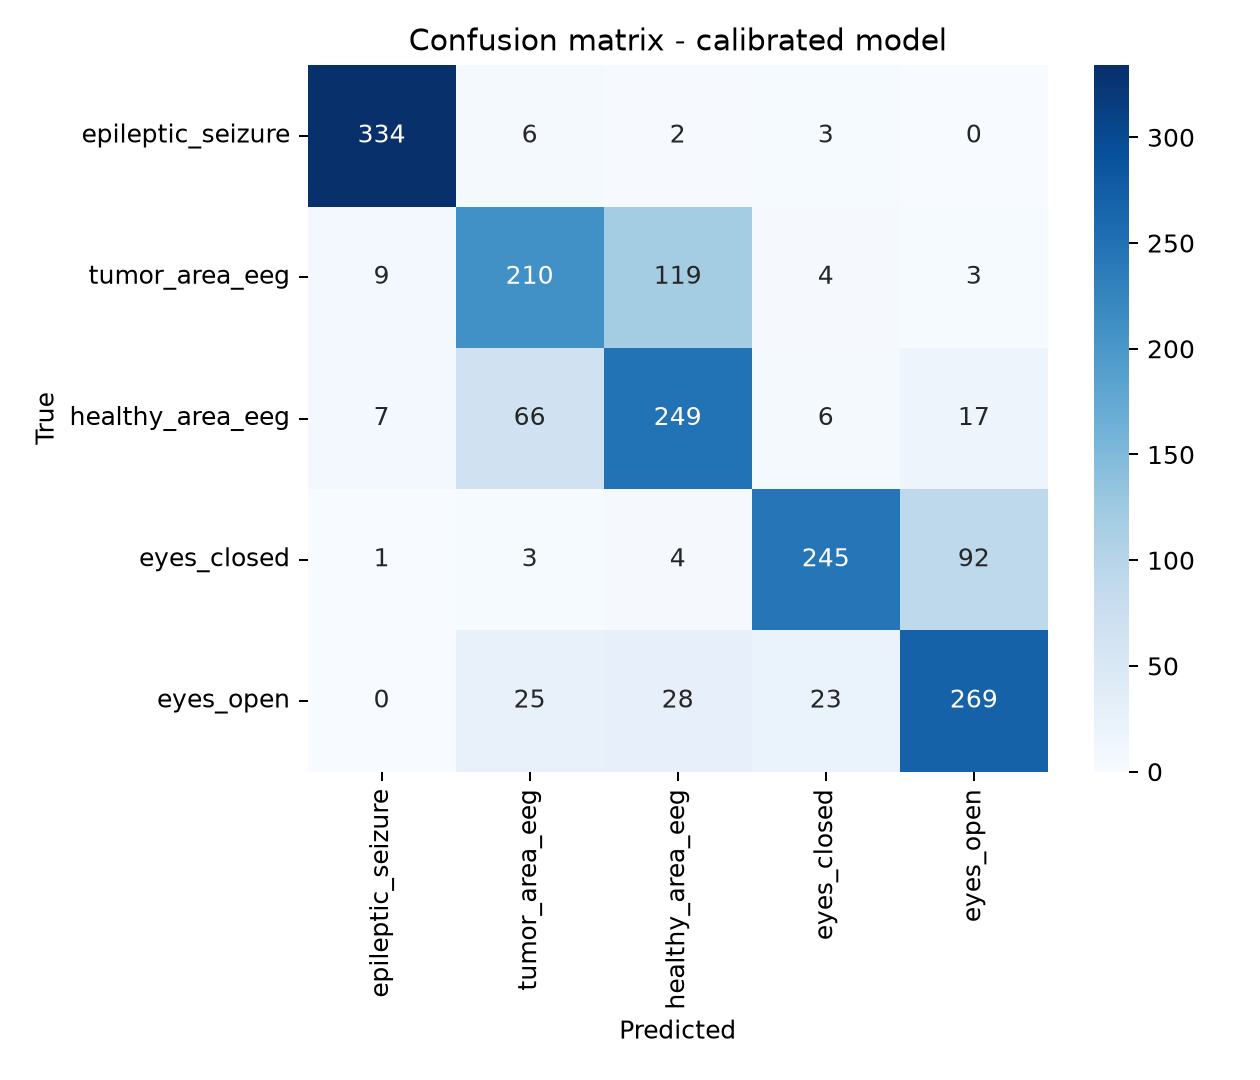

In [50]:
display(Image(filename=str(FIGURES_DIR / "confusion_matrix.png")))

### Conclusion After the Confusion Matrix

The confusion matrix confirms that the model recognizes the `epileptic_seizure` class best, with most predictions on the diagonal. The largest number of errors appears between `tumor_area_eeg` and `healthy_area_eeg`, indicating high similarity between these signals. Confusion between `eyes_closed` and `eyes_open` is also visible, but to a lesser extent than for the tumor-related classes.


## 8. Probability Calibration

Neural networks are often overconfident. Therefore, after training, temperature scaling was applied on the validation set.

Calibration does not have to change the predicted class. Its goal is to improve the reliability of probabilities.

In [51]:
calibrator.temperature

1.5682141690416223

### Conclusion After Calibration Temperature

- Temperature `T ~= 1.57` is greater than 1, which means the model was overconfident before calibration. Temperature scaling softens logits and is a standard, simple method for calibrating neural classifiers.


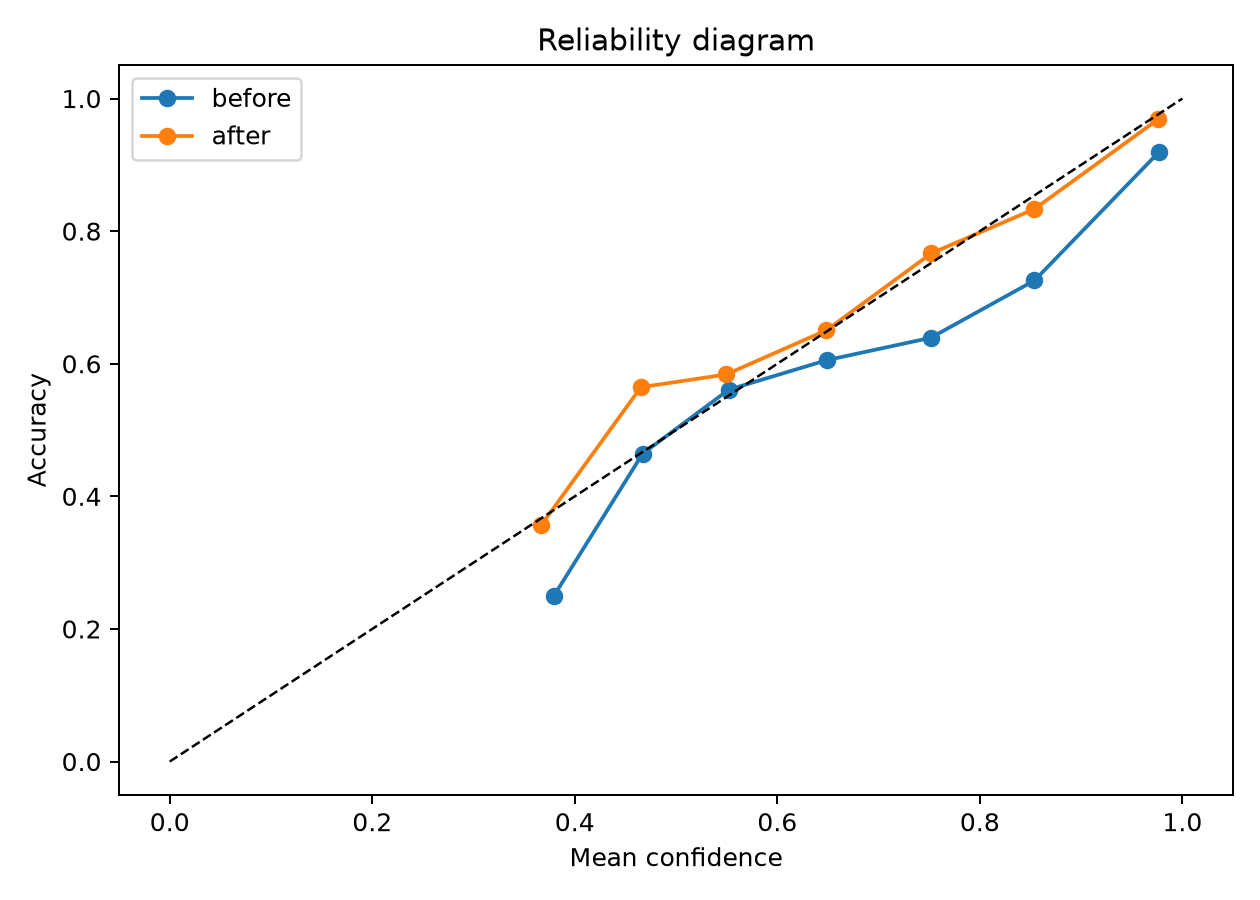

In [52]:
display(Image(filename=str(FIGURES_DIR / "reliability_diagram.png")))

### Conclusion After the Reliability Diagram

- The reliability diagram shows improved probability calibration after applying temperature scaling. After calibration, the curve is closer to the ideal calibration diagonal, which means better agreement between the model's declared confidence and actual prediction accuracy. At the same time, accuracy and F1 remain unchanged because calibration changes probability values, not the predicted class.


## 9. Prediction Uncertainty

For each test sample, the following were calculated:

- `max_probability` - maximum probability,
- `entropy` - entropy of the class distribution,
- `margin_top1_top2` - difference between the first and second most likely classes.

Based on these values, the most confident and most uncertain cases were selected.

In [ ]:
display(most_confident.head(5))
display(most_uncertain_wrong.head(5))

,index,true,pred,correct,max_probability,entropy,margin_top1_top2
1592,1592,0,0,True,1.0,0.000001,1.0
1658,1658,0,0,True,1.0,0.000003,1.0
1146,1146,0,0,True,1.0,0.000003,1.0
1566,1566,0,0,True,1.0,0.000003,1.0
930,930,0,0,True,1.0,0.000004,1.0


,index,true,pred,correct,max_probability,entropy,margin_top1_top2
1073,1073,2,3,False,0.372541,1.426543,0.122833
599,599,2,4,False,0.392216,1.392271,0.155273
577,577,1,3,False,0.370076,1.368973,0.139642
844,844,2,3,False,0.352190,1.347093,0.003062
1248,1248,4,2,False,0.372229,1.343915,0.063479


### Conclusion After Uncertainty Analysis

- The most confident correct cases have probability practically equal to `1`, very low entropy, and a very large margin between top-1 and top-2. These are good candidates for local LIME as easy cases.
- The most uncertain wrong predictions have `max_probability` of only about `0.35-0.39`, high entropy, and a small margin, so the model actually signals uncertainty where it is wrong.


## XAI Code - PFI and LIME


### Functions for PFI

PFI measures the decrease in model quality after permuting features, and the additional function aggregates the importance of individual points into signal segments.


In [ ]:
# checks each feature importance by randomly corrupting it
def permutation_importance_inline(predict_fn, x: np.ndarray, y: np.ndarray, feature_names: list[str], n_repeats: int = 3) -> pd.DataFrame:
    rng = np.random.default_rng(SEED)
    baseline = f1_score(y, predict_fn(x), average="macro")
    rows = []
    for j, name in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            x_perm = x.copy()
            x_perm[:, j] = rng.permutation(x_perm[:, j])
            score = f1_score(y, predict_fn(x_perm), average="macro")
            drops.append(baseline - score)
        rows.append({"feature": name, "importance_mean": np.mean(drops), "importance_std": np.std(drops)})
    return pd.DataFrame(rows).sort_values("importance_mean", ascending=False)


# aggregates feature importance into EEG signal fragments
def segment_importance(feature_importance: pd.DataFrame, segment_size: int = 30) -> pd.DataFrame:
    rows = []
    for _, row in feature_importance.iterrows():
        idx = int(row["feature"].lstrip("Xx"))
        segment = f"X{((idx - 1) // segment_size) * segment_size + 1}-X{min(((idx - 1) // segment_size + 1) * segment_size, 178)}"
        rows.append({**row.to_dict(), "segment": segment})
    return pd.DataFrame(rows).groupby("segment", as_index=False)["importance_mean"].sum().sort_values("importance_mean", ascending=False)


def save_importance_plot(df: pd.DataFrame, output_path: Path, title: str) -> None:
    top = df.head(20).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top.iloc[:, 0], top["importance_mean"])
    plt.xlabel("Macro F1 drop after permutation")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(output_path, dpi=180)
    plt.close()


### Functions for LIME

LIME creates local explanations for individual predictions, and the global ranking is created by aggregating many such local weights.


In [55]:
def build_lime_explainer(x_train: np.ndarray, feature_names: list[str]) -> LimeTabularExplainer:
    return LimeTabularExplainer(
        training_data=x_train,
        feature_names=feature_names,
        class_names=CLASS_NAMES,
        mode="classification",
        discretize_continuous=True,
        random_state=SEED,
    )


def map_lime_feature(text: str, feature_names: list[str]) -> str:
    for name in feature_names:
        if name in text:
            return name
    return text


def global_lime_inline(explainer, predict_proba_fn, x: np.ndarray, feature_names: list[str], n_instances: int = 120) -> pd.DataFrame:
    totals = defaultdict(float)
    counts = defaultdict(int)
    rng = np.random.default_rng(SEED)
    indices = rng.choice(len(x), size=min(n_instances, len(x)), replace=False)
    for idx in indices:
        exp = explainer.explain_instance(x[idx], predict_proba_fn, num_features=12, num_samples=3000)
        for feat, weight in exp.as_list():
            clean = map_lime_feature(feat, feature_names)
            totals[clean] += abs(weight)
            counts[clean] += 1
    rows = [{"feature": k, "mean_abs_lime_weight": totals[k] / counts[k]} for k in totals]
    return pd.DataFrame(rows).sort_values("mean_abs_lime_weight", ascending=False)


def save_lime_plot(df: pd.DataFrame) -> None:
    top = df.head(20).iloc[::-1]
    plt.figure(figsize=(8, 6))
    plt.barh(top["feature"], top["mean_abs_lime_weight"])
    plt.xlabel("Mean absolute LIME weight")
    plt.title("Global LIME importance")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "lime_global.png", dpi=180)
    plt.close()


def save_local_lime_inline(explainer, predict_proba_fn, x_test: np.ndarray, cases: dict[str, pd.DataFrame]) -> None:
    summaries = []
    for group_name, group in cases.items():
        for _, row in group.head(4).iterrows():
            idx = int(row["index"])
            exp = explainer.explain_instance(x_test[idx], predict_proba_fn, num_features=12, num_samples=3000)
            html_path = LIME_DIR / f"{group_name}_{idx}.html"
            exp.save_to_file(str(html_path))
            for feat, weight in exp.as_list():
                summaries.append({
                    "group": group_name,
                    "test_index": idx,
                    "feature": map_lime_feature(feat, explainer.feature_names),
                    "weight": weight,
                })
    pd.DataFrame(summaries).to_csv(LIME_DIR / "local_lime_summary.csv", index=False)


### Running XAI

This cell computes PFI for train/test and LIME globally and locally, then saves the results to `outputs/tables`, `outputs/figures`, and `outputs/lime`.


In [56]:
def predict_fn(x: np.ndarray) -> np.ndarray:
    logits = predict_logits(model, x.astype("float32"))
    return softmax(calibrator.transform_logits(logits)).argmax(axis=1)


def predict_proba_fn(x: np.ndarray) -> np.ndarray:
    logits = predict_logits(model, x.astype("float32"))
    return softmax(calibrator.transform_logits(logits))

for split_name, x_values, y_values in [
    ("train", splits["x_train"], splits["y_train"]),
    ("test", splits["x_test"], splits["y_test"]),
]:
    pfi = permutation_importance_inline(
        predict_fn,
        x_values,
        y_values,
        splits["feature_names"],
        n_repeats=3,
    )
    pfi.to_csv(TABLES_DIR / f"pfi_{split_name}.csv", index=False)
    save_importance_plot(pfi, FIGURES_DIR / f"pfi_{split_name}.png", f"Permutation feature importance - {split_name}")

    segments = segment_importance(pfi)
    segments.to_csv(TABLES_DIR / f"pfi_segments_{split_name}.csv", index=False)
    save_importance_plot(segments, FIGURES_DIR / f"pfi_segments_{split_name}.png", f"Segment-level PFI - {split_name}")
    if split_name == "test":
        pfi_test = pfi
        pfi_segments_test = segments

if RUN_LIME:
    explainer = build_lime_explainer(splits["x_train"], splits["feature_names"])
    lime_global = global_lime_inline(
        explainer,
        predict_proba_fn,
        splits["x_test"],
        splits["feature_names"],
        n_instances=120,
    )
    lime_global.to_csv(TABLES_DIR / "lime_global.csv", index=False)
    save_lime_plot(lime_global)
    save_local_lime_inline(explainer, predict_proba_fn, splits["x_test"], cases)

print("XAI gotowe. Wyniki zapisane w outputs/tables, outputs/figures i outputs/lime.")


XAI gotowe. Wyniki zapisane w outputs/tables, outputs/figures i outputs/lime.


## 10. Permutation Feature Importance

PFI checks how much model quality decreases after randomly permuting one feature.

Because `X1-X178` are signal time points, segments were also created in addition to individual features:

```text
X1-X30, X31-X60, X61-X90, X91-X120, X121-X150, X151-X178
```

In [ ]:
display(pfi_test.head(10))
display(pfi_segments_test)

# check the same on the training set -> then collinearity is less of a concern

,feature,importance_mean,importance_std
0,X1,0.028484,0.001420
176,X177,0.024882,0.001796
37,X38,0.024867,0.004994
62,X63,0.023814,0.002369
67,X68,0.023802,0.003796
122,X123,0.023059,0.001255
126,X127,0.022820,0.004141
32,X33,0.022800,0.002221
157,X158,0.022704,0.004765
28,X29,0.022628,0.004798


,segment,importance_mean
0,X1-X30,0.512102
1,X121-X150,0.467965
4,X61-X90,0.452709
2,X151-X178,0.451668
3,X31-X60,0.438424
5,X91-X120,0.430085


### Conclusion After the PFI Tables

- PFI on the test set indicates, among others, `X1`, `X177`, `X38`, `X63`, and `X68` as important signal points, while segment analysis shows that importance is distributed across several time fragments.
- The most important segment is `X1-X30`, and `X121-X150`, `X61-X90`, and the final part of the signal `X151-X178` also rank highly.
- Comparison with PFI on the training set shows partial agreement, because `X1`, the area around `X29`, `X68`, and later signal fragments also appear high on the training set. This is normal for correlated EEG time points.


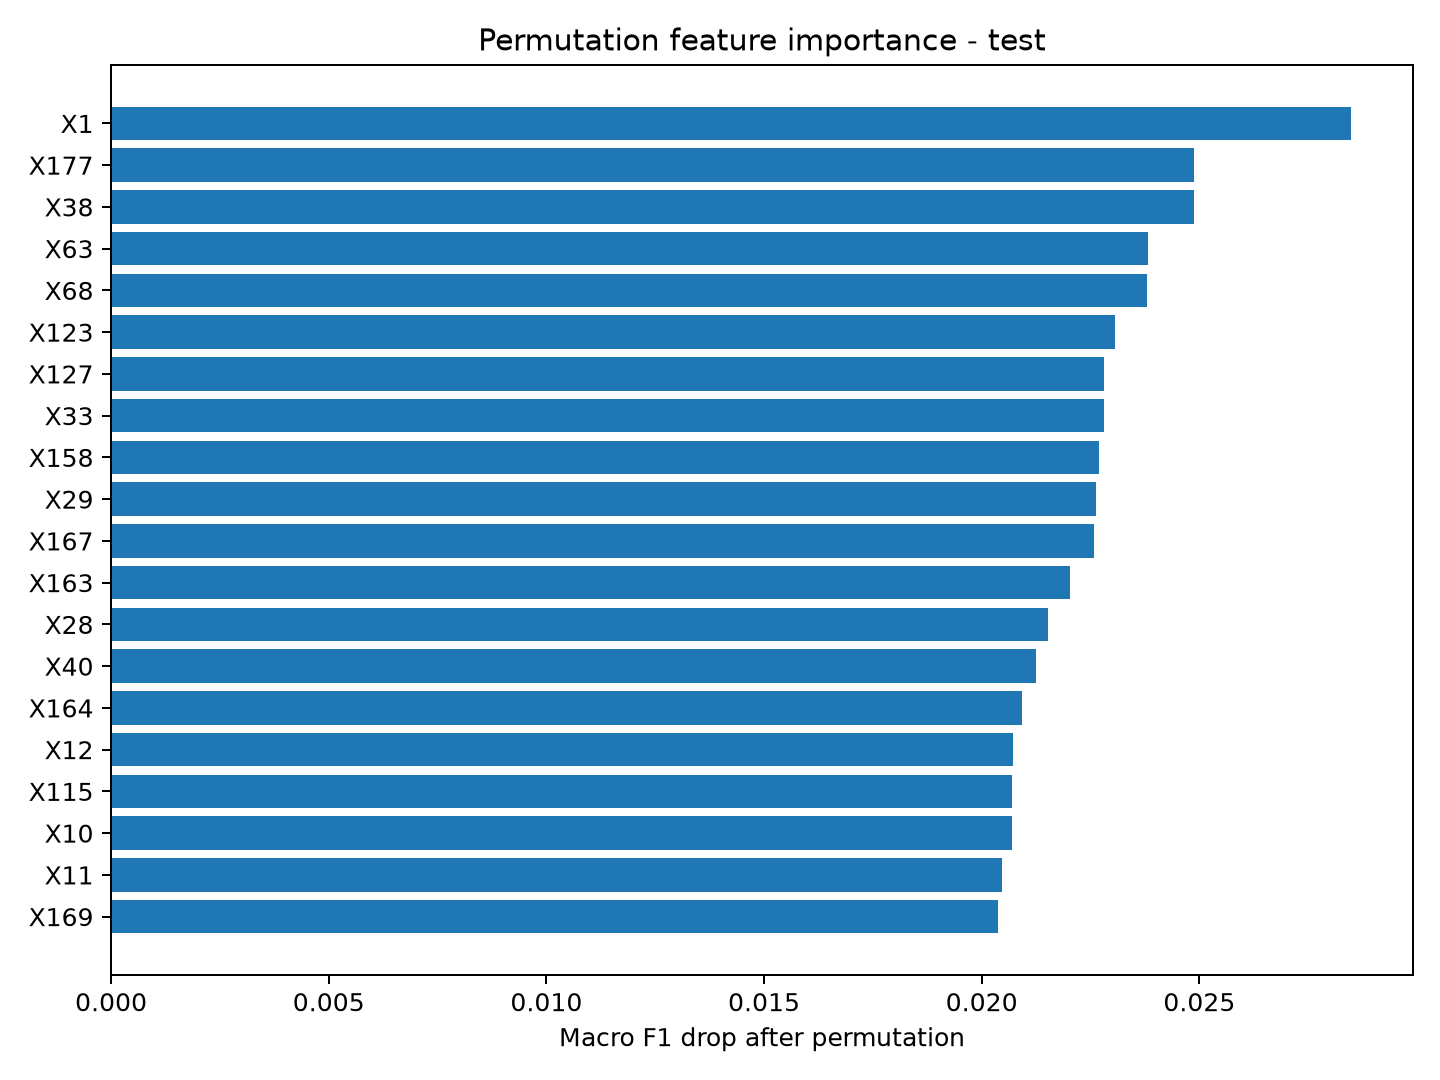

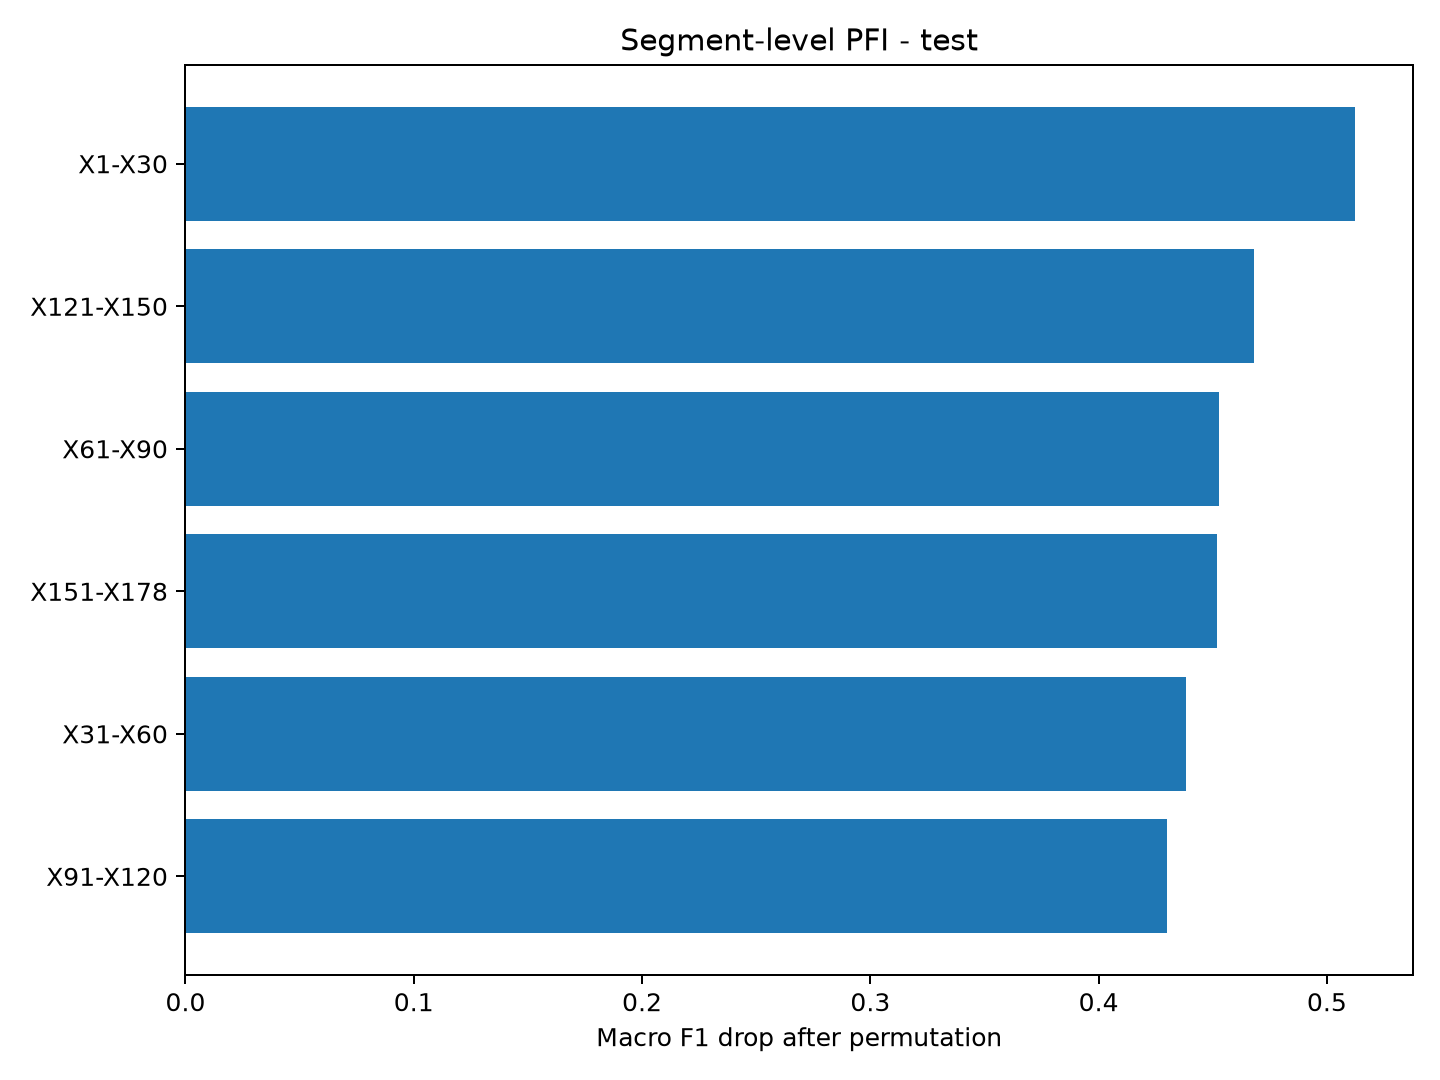

In [58]:
display(Image(filename=str(FIGURES_DIR / "pfi_test.png")))
display(Image(filename=str(FIGURES_DIR / "pfi_segments_test.png")))

### Conclusion After the PFI Plots

- The plots confirm that a single `X` point should not be overinterpreted. Neighboring signal samples are dependent, so the importance of time intervals is a more stable interpretation.
- In this run, the model uses the beginning of the signal (`X1-X30`) most strongly, but middle and final fragments also remain important, so the decision is not based on one short interval only.


## 11. LIME

LIME was used in two ways:

1. **Globally** - aggregation of many local explanations.
2. **Locally** - separate explanations for confident and uncertain cases.

Local results are saved as HTML files in `outputs/lime/`.


,feature,mean_abs_lime_weight
0,X9,0.006373
6,X5,0.006164
8,X7,0.006056
7,X3,0.006011
3,X1,0.005769
4,X8,0.005680
1,X2,0.005644
2,X6,0.005603
5,X4,0.005531


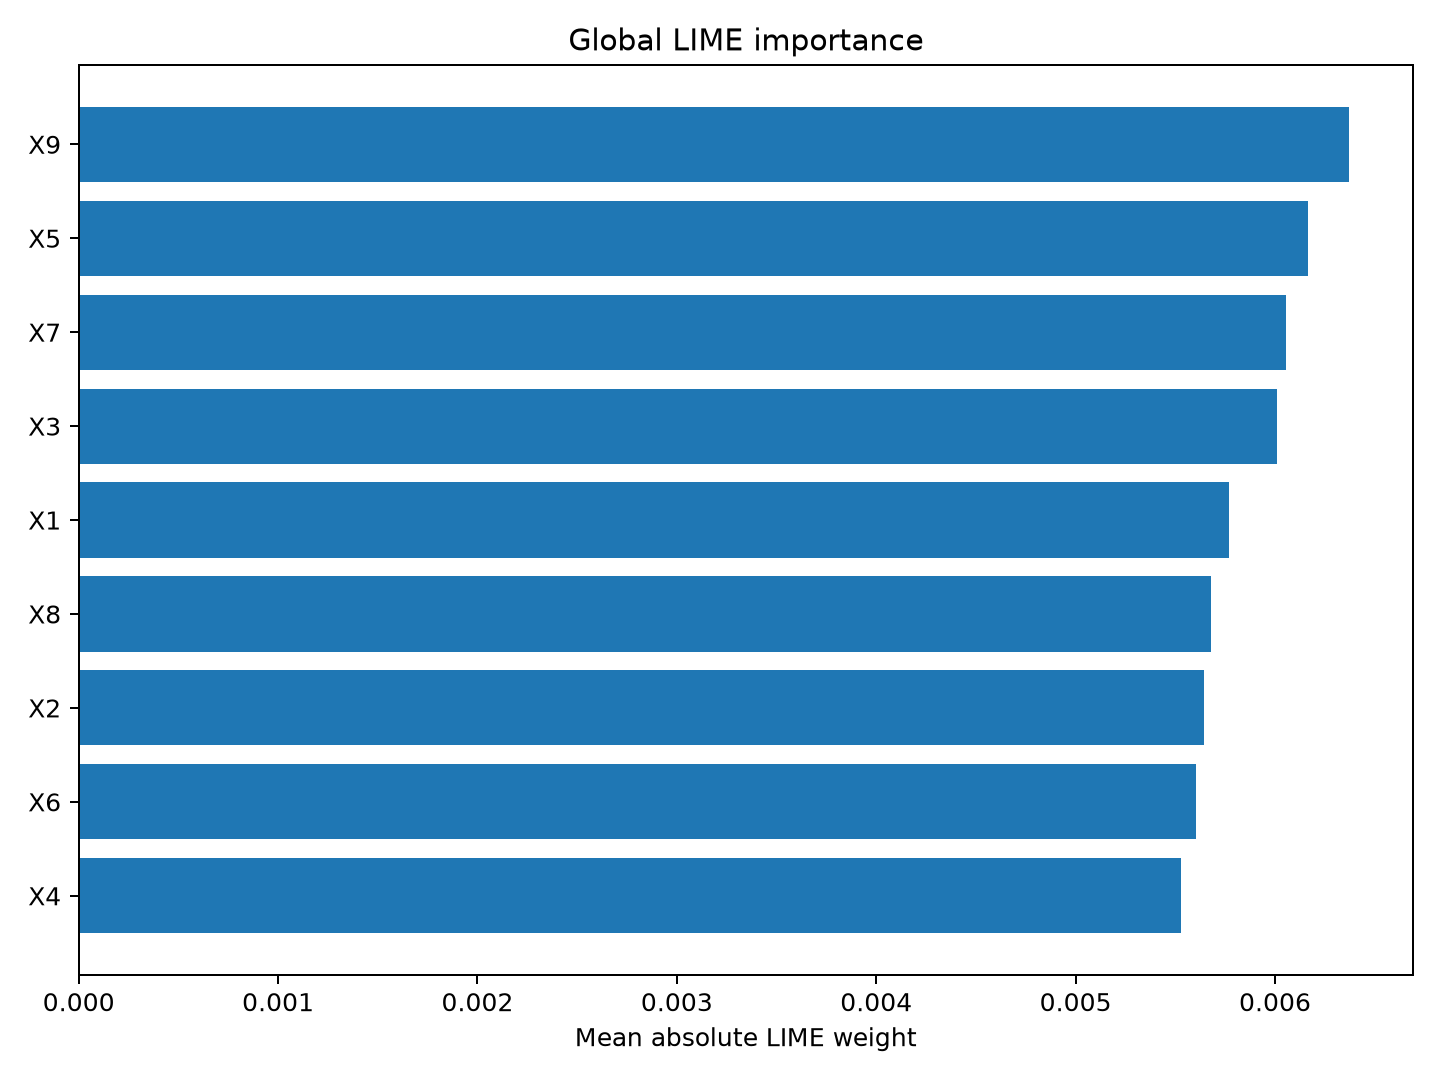

In [59]:
display(lime_global)
display(Image(filename=str(FIGURES_DIR / "lime_global.png")))

### Conclusion After Global LIME

Global LIME analysis shows that the strongest influence on model predictions comes mainly from the initial EEG signal points, especially `X9`, `X5`, `X7`, `X3`, and `X1`. This means that the model strongly uses information from the beginning of the signal when making decisions.

The differences between individual feature weights are not very large, which suggests that the model does not rely on one dominant point but uses several neighboring signal samples.


In [60]:
lime_files = sorted(LIME_DIR.glob("*.html"))
pd.DataFrame({"lokalne_wyjasnienia_LIME": [p.name for p in lime_files[:12]]})

,lokalne_wyjasnienia_LIME
0,most_confident_correct_1026.html
1,most_confident_correct_1105.html
2,most_confident_correct_1146.html
3,most_confident_correct_1339.html
4,most_confident_correct_1566.html
5,most_confident_correct_1572.html
6,most_confident_correct_1592.html
7,most_confident_correct_1658.html
8,most_confident_correct_332.html
9,most_uncertain_correct_1075.html


## 13. Final Conclusions

- The model correctly addresses the EEG multiclass classification task and achieves a stable test result of about `0.758` for accuracy, balanced accuracy, and macro F1.
- The best-recognized class is seizure EEG (`F1 ~= 0.960`), while the hardest classes are classes 2 and 3, which is consistent with their signal similarity.
- Calibration is successful: it does not change class decisions, but it improves probability quality (`ECE` decreases from about `0.063` to about `0.032`).
- Uncertainty analysis is intuitive: uncertain wrong cases have high entropy and a small top-1/top-2 margin, while confident cases have probabilities practically equal to 1.
- PFI and LIME do not produce identical rankings, but together they show that the model uses many EEG signal intervals, especially the beginning and selected later fragments.
